# Trade-augmented ("merged") price stream vs front-levels-only — with a staleness sweep

The BBO (`front_levels`) feed is a **slow sampler** of the true top-of-book — on
`eth_usdt_p` the median snapshot gap is **~20 ms on byb and okx** (p90 100–160 ms),
versus **sub-millisecond on bin**. Between snapshots the price still moves, and
**trades reveal it**: a trade tells us a side's price at its own `exchange_time`,
often fresher than the last BBO snapshot.

**The merge (price-only).** Keep `best_bid` / `best_ask`, each tagged with the
`exchange_time` of the message that last set it. Walk all messages in `rx_time`
order. A snapshot always refreshes both sides. A **trade overrides its side only
if its `exchange_time` is more than a threshold ε newer than the freshest
snapshot** — i.e. only when the quote is genuinely stale. Sources per side:

| event | updates | to |
|-------|---------|----|
| BBO snapshot | both sides | `bid_prc` / `ask_prc` @ snapshot `exchange_time` |
| trade, `aggressor=Bid` (buy lifts the ask), if `trade_exch > snap_exch + ε` | **ask** | trade `prc` @ trade `exchange_time` |
| trade, `aggressor=Ask` (sell hits the bid), if `trade_exch > snap_exch + ε` | **bid** | trade `prc` @ trade `exchange_time` |

**ε = 0** is "any trade fresher than the quote wins" (the maximal merge). Larger ε
only trusts a trade when the quote is ≥ ε stale. Volume can't be merged this way,
so this is explicitly a **price-only** stream.

**Question:** per exchange on `eth_usdt_p`, how does the merge's value vary with ε —
and is there a setting that helps the slow feeds without hurting the fast one?

### Two verified data facts baked in
- **Aggressor → side** (checked on real blocks for all three venues): `Bid`-aggressor
  trades execute at the **ask** (≈ mid + ½-spread), `Ask`-aggressor at the **bid**.
- **Binance-perp zero prints.** ~0.25% of `bin_*_p` trades carry `prc=0, qty=0` at
  real, contiguous Binance trade-ids — USD-M futures **aggTrade** entries for
  trade-id slots consumed by **insurance-fund / ADL** fills, which Binance
  documents it *excludes from aggregation* (spot has a raw `@trade` feed and no
  liquidation engine; byb/okx clean). Not market fills — drop `prc<=0 & qty<=0`.

In [1]:
import gc
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from boba.io import list_blocks, load_block

COIN = "eth_usdt_p"
EXCHANGES = ["bin", "byb", "okx"]
EPS_MS = [0, 0.5, 1, 2, 3, 5, 7, 10, 15, 20, 30, 50]     # staleness thresholds to sweep
I64MIN = np.iinfo(np.int64).min

## Load raw streams (`boba.io` only — no dataset classes)

In [2]:
def load_streams(listing, block=None):
    flb, tdb = list_blocks(listing, "front_levels"), list_blocks(listing, "trade")
    blk = block or flb[0]
    fl = (load_block(blk, listing, "front_levels")
          .select("rx_time", "exchange_time", "bid_prc", "ask_prc")
          .drop_nulls().sort("rx_time"))
    tblk = blk if blk in set(tdb) else tdb[0]
    td = (load_block(tblk, listing, "trade")
          .select("rx_time", "exchange_time", "aggressor", "prc", "qty")
          .filter((pl.col("prc") > 0) & (pl.col("qty") > 0))   # drop Binance-perp insurance/ADL prints
          .drop_nulls().sort("rx_time"))
    return blk, fl, td

def _ns(s):
    return s.cast(pl.Int64).to_numpy()

## The merge — newest-by-exchange-time wins, gated by ε

Per side, gather its update events (snapshots + the relevant trades) ordered by
`rx_time`, hold the price of the most-recent-*by-exchange-time* event so far, but
**only admit a trade if it is more than ε newer than the freshest snapshot to
date**. The snapshot reference (`ref`) is a single cumulative max computed once,
so sweeping ε is just a mask + two `np.maximum.accumulate` calls — no re-sorting.

In [3]:
def held_newer(ex, px):
    # events already in rx order -> (held_price, held_exch_time): price of the
    # newest-by-exchange_time event seen so far.
    run = np.maximum.accumulate(ex)
    prev = np.empty_like(run); prev[0] = I64MIN; prev[1:] = run[:-1]
    upd = ex > prev                                   # strictly newer => adopt
    pos = np.where(upd, np.arange(len(ex)), -1)
    hp = np.maximum.accumulate(pos)
    return px[hp], ex[hp]

def held_newer_ref(ex, px):
    # dead-simple O(n) reference loop (independent oracle).
    best_ex, best_px = I64MIN, np.nan
    op = np.empty(len(px), np.float64); oe = np.empty(len(ex), np.int64)
    for i in range(len(ex)):
        if ex[i] > best_ex:
            best_ex, best_px = ex[i], px[i]
        op[i], oe[i] = best_px, best_ex
    return op, oe

def side_combined(snap_rx, snap_ex, snap_px, tr_rx, tr_ex, tr_px):
    # one rx-ordered event list per side + the running freshest-snapshot exch_time
    rx = np.concatenate([snap_rx, tr_rx])
    ex = np.concatenate([snap_ex, tr_ex])
    px = np.concatenate([snap_px, tr_px])
    is_tr = np.concatenate([np.zeros(len(snap_rx), bool), np.ones(len(tr_rx), bool)])
    o = np.argsort(rx, kind="stable")
    rx, ex, px, is_tr = rx[o], ex[o], px[o], is_tr[o]
    ref = np.maximum.accumulate(np.where(is_tr, I64MIN, ex))   # freshest snapshot exch at/<= each pos
    return dict(rx=rx, ex=ex, px=px, is_tr=is_tr, ref=ref)

def side_at_eps(c, eps_ns):
    # admit snapshots always; admit a trade only if > ref + eps; then hold newest-by-exch
    keep = (~c["is_tr"]) | (c["ex"] > c["ref"] + eps_ns)
    hp, hx = held_newer(c["ex"][keep], c["px"][keep])
    return c["rx"][keep], hp, hx

def step_at(step_rx, step_val, q):
    j = np.searchsorted(step_rx, q, "right") - 1
    assert j.min() >= 0, "query precedes first step event"   # guard numpy's silent -1 wrap
    return step_val[j]

def build_streams(listing, block=None):
    blk, fl, td = load_streams(listing, block)
    s_rx, s_ex = _ns(fl["rx_time"]), _ns(fl["exchange_time"])
    bid, ask = fl["bid_prc"].to_numpy(), fl["ask_prc"].to_numpy()
    agg = td["aggressor"].to_numpy()
    t_rx, t_ex, t_px = _ns(td["rx_time"]), _ns(td["exchange_time"]), td["prc"].to_numpy()
    buy, sell = agg == "Bid", agg == "Ask"            # buy lifts ask, sell hits bid
    return dict(listing=listing, block=blk, n_snap=len(fl), n_trades=len(td),
                s_rx=s_rx, s_ex=s_ex, bid=bid, ask=ask, mid=(bid + ask) / 2.0,
                t_rx=t_rx, t_px=t_px, buy=buy, sell=sell,
                ask_c=side_combined(s_rx, s_ex, ask, t_rx[buy], t_ex[buy], t_px[buy]),
                bid_c=side_combined(s_rx, s_ex, bid, t_rx[sell], t_ex[sell], t_px[sell]))

## Validate the fast merge against the dead-simple reference

Project rule: the optimized path must match an independent, trivially-simple
oracle on a real block. The vectorized `held_newer` must equal the explicit
Python loop `held_newer_ref`, bit-for-bit.

In [4]:
_b, _fl, _td = load_streams("byb_" + COIN)
_s_rx, _s_ex = _ns(_fl["rx_time"]), _ns(_fl["exchange_time"])
_ask = _fl["ask_prc"].to_numpy()
_agg = _td["aggressor"].to_numpy(); _buy = _agg == "Bid"
_o = np.argsort(np.concatenate([_s_rx, _ns(_td["rx_time"])[_buy]]), kind="stable")[:200_000]
_ex = np.concatenate([_s_ex, _ns(_td["exchange_time"])[_buy]])[_o]
_px = np.concatenate([_ask, _td["prc"].to_numpy()[_buy]])[_o]
_rp, _re = held_newer_ref(_ex, _px)
_vp, _vx = held_newer(_ex, _px)
assert np.array_equal(_re, _vx) and np.allclose(_rp, _vp, equal_nan=True)
print(f"vectorized merge == reference loop on {len(_o):,} ask-side events  OK")

vectorized merge == reference loop on 200,000 ask-side events  OK


## Metric — predict the next BBO snapshot mid (at a given ε)

The cleanest causal test of "fresher / more accurate": just before each snapshot
*k* arrives, what's the best estimate of its mid?
- **front-levels-only** holds snapshot *k−1*'s mid.
- **merged(ε)** holds *k−1* plus any trades admitted under threshold ε.
- **truth** = snapshot *k*'s mid (independent, revealed next).

Report `R² = 1 − SS_merged / SS_bbo` (variance of next-snapshot error removed),
RMSE in bps of mid, and — conditional on the gaps a trade informed — win-rate
(merge strictly closer to truth) and freshness gain. Evaluating *before* snapshot
*k* means no lookahead; using *k* as truth is conservative.

In [5]:
def eval_eps(b, eps_ns):
    ar_rx, ar_hp, ar_hx = side_at_eps(b["ask_c"], eps_ns)
    br_rx, br_hp, br_hx = side_at_eps(b["bid_c"], eps_ns)
    s_rx, mid, s_ex = b["s_rx"], b["mid"], b["s_ex"]
    q = s_rx[1:] - 1                                  # just before snapshot k
    merged_pred = (step_at(ar_rx, ar_hp, q) + step_at(br_rx, br_hp, q)) / 2.0
    bbo_pred, truth = mid[:-1], mid[1:]
    err_b, err_m = bbo_pred - truth, merged_pred - truth
    mdiff = merged_pred != bbo_pred                   # a trade informed this gap
    bps = 1e4 / np.median(mid)
    rmse = lambda e: float(np.sqrt(np.mean(e ** 2)) * bps)
    leg_hx = np.maximum(step_at(ar_rx, ar_hx, q), step_at(br_rx, br_hx, q))
    fresh = (leg_hx - s_ex[:-1]) / 1e6
    return dict(
        exchange=b["listing"].split("_")[0], eps_ms=eps_ns / 1e6,
        R2=1 - np.sum(err_m ** 2) / np.sum(err_b ** 2),
        rmse_bbo=rmse(err_b), rmse_merged=rmse(err_m),
        gaps_informed=float(mdiff.mean()),
        win=float(np.mean(np.abs(err_m[mdiff]) < np.abs(err_b[mdiff]))) if mdiff.any() else float("nan"),
        fresh_ms=float(np.median(fresh[mdiff])) if mdiff.any() else float("nan"),
    )

## Sweep ε for each exchange

ε = 0 reproduces the maximal merge (every fresher trade admitted); each larger ε
admits only trades that beat the freshest quote by more than ε ms.

In [6]:
rows, offs, builds = [], [], {}
for ex in EXCHANGES:
    b = build_streams(f"{ex}_{COIN}")
    for e in EPS_MS:
        rows.append(eval_eps(b, int(e * 1_000_000)))
    # how far ahead of the freshest book snapshot (in exchange-time) do this venue's trades look?
    d_ms = np.concatenate([
        b["ask_c"]["ex"][b["ask_c"]["is_tr"]] - b["ask_c"]["ref"][b["ask_c"]["is_tr"]],
        b["bid_c"]["ex"][b["bid_c"]["is_tr"]] - b["bid_c"]["ref"][b["bid_c"]["is_tr"]],
    ]) / 1e6
    offs.append(dict(exchange=ex, ahead_median_ms=float(np.median(d_ms)),
                     ahead_p90_ms=float(np.percentile(d_ms, 90)), frac_gt_50ms=float(np.mean(d_ms > 50))))
    if ex == "byb":
        builds["byb"] = b                              # keep the small one for the plot
    else:
        del b; gc.collect()

sweep = pl.DataFrame(rows)
pl.Config.set_tbl_rows(40); pl.Config.set_tbl_cols(20); pl.Config.set_float_precision(3)
sweep.with_columns([
    (pl.col("gaps_informed") * 100).round(2).alias("gaps_informed_%"),
    (pl.col("win") * 100).round(1).alias("win_%"),
]).drop("gaps_informed", "win").pivot(values="R2", index="eps_ms", on="exchange").rename(
    {"bin": "R2_bin", "byb": "R2_byb", "okx": "R2_okx"})

eps_ms,R2_bin,R2_byb,R2_okx
f64,f64,f64,f64
0.000,-13.201,0.286,0.476
0.500,-13.201,0.286,0.476
1.000,-12.770,0.284,0.474
2.000,-12.791,0.279,0.461
3.000,-12.820,0.266,0.451
5.000,-12.807,0.206,0.395
7.000,-12.803,0.120,0.288
10.000,-12.794,0.056,0.085
15.000,-12.801,0.050,0.080


### R² vs ε  —  byb/okx peak at ε=0 and decay; bin stays negative at every ε (ε can't rescue it)

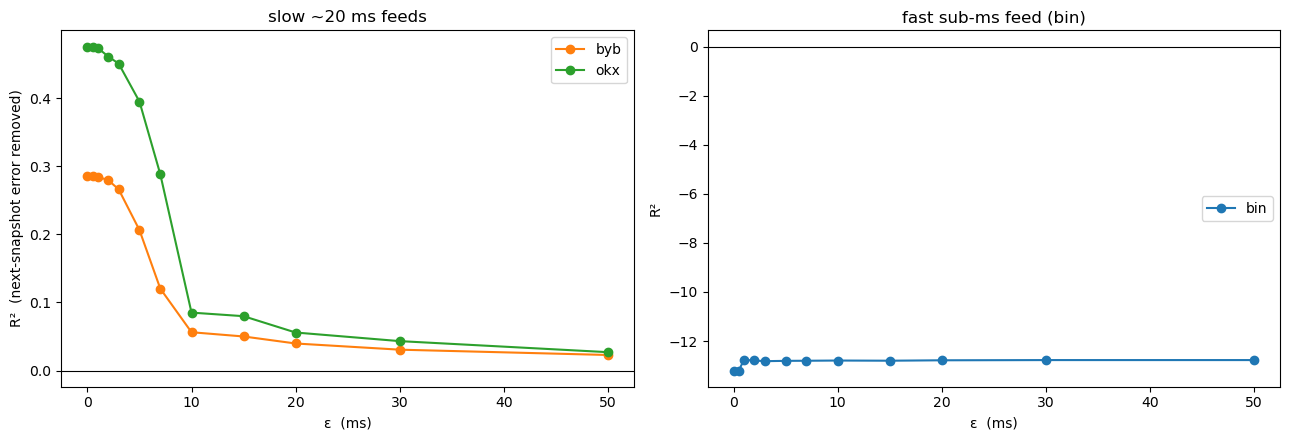

In [7]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.5))
for ex, c in [("byb", "C1"), ("okx", "C2")]:
    d = sweep.filter(pl.col("exchange") == ex).sort("eps_ms")
    axL.plot(d["eps_ms"], d["R2"], "o-", color=c, label=ex)
axL.axhline(0, lw=0.8, color="k"); axL.set_xlabel("ε  (ms)"); axL.set_ylabel("R²  (next-snapshot error removed)")
axL.set_title("slow ~20 ms feeds"); axL.legend()
d = sweep.filter(pl.col("exchange") == "bin").sort("eps_ms")
axR.plot(d["eps_ms"], d["R2"], "o-", color="C0", label="bin")
axR.axhline(0, lw=0.8, color="k"); axR.set_xlabel("ε  (ms)"); axR.set_ylabel("R²")
axR.set_title("fast sub-ms feed (bin)"); axR.legend()
fig.tight_layout()

### Best ε per exchange (max R²)

In [8]:
best = (sweep.sort(["exchange", "R2"], descending=[False, True])
        .group_by("exchange", maintain_order=True).first()
        .select("exchange", pl.col("eps_ms").alias("best_eps_ms"), "R2", "rmse_bbo", "rmse_merged",
                (pl.col("gaps_informed") * 100).round(2).alias("gaps_informed_%"),
                (pl.col("win") * 100).round(1).alias("win_%"), "fresh_ms")
        .sort("exchange"))
best

exchange,best_eps_ms,R2,rmse_bbo,rmse_merged,gaps_informed_%,win_%,fresh_ms
str,f64,f64,f64,f64,f64,f64,f64
"""bin""",1.000,-12.770,0.018,0.068,9.500,0.200,0.000
"""byb""",0.000,0.286,0.110,0.093,2.680,98.600,7.000
"""okx""",0.000,0.476,0.092,0.067,1.880,99.700,7.000


### Why ε diverges by venue — how far *ahead* of the book the trade feed looks

ε is a *lower* bound: a trade is admitted only if its `exchange_time` exceeds the
freshest snapshot by more than ε. So ε discards the *near-zero* trades and keeps
the *far-ahead* tail. On bin the harm lives in that tail — trades whose
`exchange_time` runs tens of ms ahead of the book **latch** the side (~14 ms) and
block real snapshots — so a lower-bound ε can't remove them. (byb actually has
*more* far-ahead trades, but they help there: they replace a 20 ms-stale quote,
not a live one.)

In [9]:
pl.DataFrame(offs).with_columns([
    pl.col("ahead_median_ms").round(1), pl.col("ahead_p90_ms").round(1),
    (pl.col("frac_gt_50ms") * 100).round(2).alias("frac_>50ms_%"),
]).drop("frac_gt_50ms")

exchange,ahead_median_ms,ahead_p90_ms,frac_>50ms_%
str,f64,f64,f64
"""bin""",0.000,5.000,2.240
"""byb""",5.000,81.000,13.750
"""okx""",7.000,71.000,13.600


## Visual — the merge anticipating the next snapshot (byb, ε = 0)

byb's most volatile second, both mids on a 1 ms grid. Front-levels-only is a
coarse ~20 ms staircase; the merged mid steps mid-gap on trades, reaching the
next snapshot's level early. Trades marked on their side (▲ buy at ask, ▼ sell at bid).

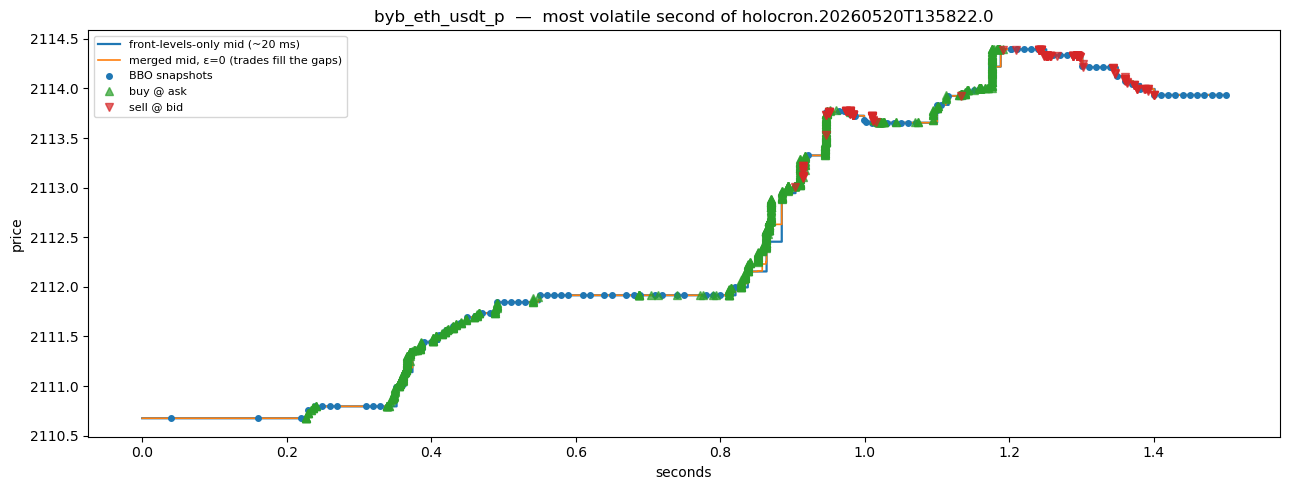

In [10]:
b = builds["byb"]
s_rx, mid = b["s_rx"], b["mid"]
ar_rx, ar_hp, _ = side_at_eps(b["ask_c"], 0)
br_rx, br_hp, _ = side_at_eps(b["bid_c"], 0)
sec = (s_rx - s_rx[0]) // 1_000_000_000
uniq, first = np.unique(sec, return_index=True)
rng = np.maximum.reduceat(mid, first) - np.minimum.reduceat(mid, first)
best_sec = int(uniq[np.argmax(rng)])
t0 = s_rx[0] + max(0, best_sec * 1_000_000_000 - 250_000_000)   # keep grid within the data
t1 = min(t0 + 1_500_000_000, s_rx[-1])

grid = np.arange(t0, t1, 1_000_000)                    # 1 ms
bbo = step_at(s_rx, mid, grid)
merged = (step_at(ar_rx, ar_hp, grid) + step_at(br_rx, br_hp, grid)) / 2.0
ts = lambda a: (a - t0) / 1e9

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(ts(grid), bbo, drawstyle="steps-post", lw=1.6, label="front-levels-only mid (~20 ms)")
ax.plot(ts(grid), merged, drawstyle="steps-post", lw=1.2, label="merged mid, ε=0 (trades fill the gaps)")
sw = (s_rx >= t0) & (s_rx < t1)
ax.plot(ts(s_rx[sw]), mid[sw], "o", ms=4, color="C0", label="BBO snapshots")
tw = (b["t_rx"] >= t0) & (b["t_rx"] < t1)
for mask, mk, lab in [(b["buy"], "^", "buy @ ask"), (b["sell"], "v", "sell @ bid")]:
    m = tw & mask
    ax.plot(ts(b["t_rx"][m]), b["t_px"][m], mk, ms=6, alpha=0.7, label=lab)
ax.set_xlabel("seconds"); ax.set_ylabel("price"); ax.set_title(f"byb_{COIN}  —  most volatile second of {b['block']}")
ax.legend(loc="best", fontsize=8); fig.tight_layout()

## Cross-block validation — does it hold across days?

One block could be a fluke. Pick **6 substantial blocks** (≥ half the median
`front_levels` row count, to skip short session fragments) spanning the full
~3-week archive, and run the ε=0 merge metric per venue on each. *(This is the
slow section — it loads 18 block×venue combinations, including a 55 M-row bin
block.)*

Two independent "busy" axes are covered: **`tier`** is the trade-**count** tercile
(how the blocks were sampled), while **`vol_bps`** is 1-second realized **price**
volatility. They don't align — a low-count day can still be volatile — so the six
blocks span a 2-D range of conditions (vol ≈ 0.6–2.1 bps), a stronger test than
either axis alone.

In [11]:
XBLOCKS = [   # (label, block-id, activity tier) — substantial blocks across 2026-05-20 .. 06-07
    ("0602T142714",   "holocron.20260602T142714.0", "quiet"),
    ("0602T092726",   "holocron.20260602T092726.0", "quiet"),
    ("0526T092411",   "holocron.20260526T092411.0", "mid"),
    ("0520T135822.1", "holocron.20260520T135822.1", "mid"),
    ("0528T062557.1", "holocron.20260528T062557.1", "busy"),
    ("0607T190441",   "holocron.20260607T190441.0", "busy"),
]
xr = []
for label, blk, tier in XBLOCKS:
    for ex in EXCHANGES:
        b = build_streams(f"{ex}_{COIN}", blk)
        r = eval_eps(b, 0)                             # ε = 0 (best for the slow feeds)
        sec = (b["s_rx"] - b["s_rx"][0]) // 1_000_000_000
        _, fi = np.unique(sec, return_index=True)
        vol = float(np.std(np.diff(np.log(b["mid"][fi]))) * 1e4)   # 1s realized vol, bps
        xr.append(dict(block=label, tier=tier, exchange=ex, vol_bps=round(vol, 2),
                       R2=round(r["R2"], 3), rmse_bbo=round(r["rmse_bbo"], 3),
                       rmse_merged=round(r["rmse_merged"], 3), win_pct=round(r["win"] * 100, 1)))
        del b; gc.collect()
xdf = pl.DataFrame(xr)
pl.Config.set_tbl_rows(20)
xdf.sort("block", "exchange")

block,tier,exchange,vol_bps,R2,rmse_bbo,rmse_merged,win_pct
str,str,str,f64,f64,f64,f64,f64
"""0520T135822.1""","""mid""","""bin""",0.570,-13.186,0.016,0.061,0.300
"""0520T135822.1""","""mid""","""byb""",0.620,0.269,0.092,0.079,98.200
"""0520T135822.1""","""mid""","""okx""",0.590,0.475,0.084,0.061,99.800
"""0526T092411""","""mid""","""bin""",1.020,-12.042,0.021,0.077,0.300
"""0526T092411""","""mid""","""byb""",1.050,0.277,0.114,0.097,97.200
"""0526T092411""","""mid""","""okx""",1.050,0.503,0.122,0.086,99.500
"""0528T062557.1""","""busy""","""bin""",0.720,-6.111,0.033,0.088,0.300
"""0528T062557.1""","""busy""","""byb""",0.750,0.267,0.101,0.087,97.800
"""0528T062557.1""","""busy""","""okx""",0.730,0.516,0.101,0.070,99.600


**Robust.** byb R² stays **+0.27 … +0.35** and okx **+0.48 … +0.57** on every block —
quiet or busy — while bin is **negative on every block** (−3 to −13, least-bad on
high-vol days where its baseline error is larger). Win-rate is 97–100% for byb/okx
and <1% for bin throughout. The single-block conclusion holds across the archive:
**merge byb/okx, leave bin as-is.** (If anything the merge helps the slow feeds
slightly *more* on busier/higher-vol days.)

## Read-out

- **byb / okx (slow ~20 ms feed): the merge helps, and best ε ≈ 0.** R² peaks at
  ε=0 (**0.29 / 0.48** of next-snapshot error removed) and decays *monotonically*
  as ε rises — by ε≈10 ms (half the snapshot gap) most of the gain is gone
  (R² ≈ 0.06 / 0.09) and trade-informed gaps fall from ~2–3% to <0.5%. The value
  is carried by the bulk of trades only a few ms fresher than the stale quote
  (median ~5–7 ms ahead of book); ε just throws them away. A ≤1 ms ε is identical
  to 0, so **use ε = 0** on these venues.
- **bin (sub-ms feed): ε cannot rescue the merge** — R² is pinned near **−12.8 at
  every ε up to 50 ms**. Two facts combine: (1) bin's quote is already near-perfect
  (RMSE 0.018 bps), so any override with the *just-lifted* stale price can only add
  noise; (2) a *lower*-bound ε can't drive overrides to zero — the tail of trades
  whose `exchange_time` runs far ahead of the book (offsets table) each **latches**
  its side ~14 ms, keeping ~9% of gaps overridden even at ε=50 ms. So the
  regression survives the whole sweep.

**Takeaway:** ε is the right knob for the *slow* feeds (answer: ε≈0) and the wrong
one for the *fast* feed. For a single cross-venue rule, gate on *relative* feed
speed — merge only when the quote feed is materially slower than the trade feed
(skip bin) — and/or add a **latch guard**: reject a trade whose `exchange_time`
runs more than a few ms *ahead* of the freshest snapshot (an *upper* cap, the
opposite of ε). Next: confirm across more blocks, then sweep the latch-guard cap.

## Does it hold on SPOT? (and do exchanges differ?)

Everything above is perp (`eth_usdt_p`). Spot venues can behave differently — most
importantly the **aggressor → side mapping**, which the whole merge depends on (a
buy must update the ask, a sell the bid). Rather than assume the perp mapping, we
**auto-detect it per listing**: bucket each trade against the last stale mid and
ask which aggressor label sits at the *ask* (above mid). Then run the same ε=0
merge with the correct per-listing mapping, on spot and perp side by side.

In [12]:
SPOT = "eth_usdt"   # spot (no _p suffix)

def _bid_lifts_ask(s_rx, bid, ask, t_rx, t_px, agg):
    # which aggressor sits at the ASK? True => 'Bid'-aggressor lifts the ask (the standard map)
    j = np.searchsorted(s_rx, t_rx, "right") - 1
    ok = j >= 0; jj = j[ok]
    mid = (bid + ask) / 2.0
    hs = np.where((ask[jj] - bid[jj]) > 0, (ask[jj] - bid[jj]) / 2.0, np.nan)
    rel = (t_px[ok] - mid[jj]) / hs                       # >0 => trade above mid => at the ask
    return float(np.nanmean(rel[agg[ok] == "Bid"])) > 0

def merge_r2(exch, market):
    L = f"{exch}_{market}"
    blk = list_blocks(L, "front_levels")[0]
    fl = (load_block(blk, L, "front_levels").select("rx_time", "exchange_time", "bid_prc", "ask_prc")
          .drop_nulls().sort("rx_time"))
    td = (load_block(blk, L, "trade").select("rx_time", "exchange_time", "aggressor", "prc", "qty")
          .filter((pl.col("prc") > 0) & (pl.col("qty") > 0)).drop_nulls().sort("rx_time"))
    s_rx, s_ex = _ns(fl["rx_time"]), _ns(fl["exchange_time"])
    bid, ask = fl["bid_prc"].to_numpy(), fl["ask_prc"].to_numpy(); mid = (bid + ask) / 2.0
    t_rx, t_ex, t_px = _ns(td["rx_time"]), _ns(td["exchange_time"]), td["prc"].to_numpy()
    agg = td["aggressor"].to_numpy()
    std = _bid_lifts_ask(s_rx, bid, ask, t_rx, t_px, agg)
    lift_ask = (agg == "Bid") if std else (agg == "Ask")  # trades that hit the ASK (per detected map)
    a = side_at_eps(side_combined(s_rx, s_ex, ask, t_rx[lift_ask], t_ex[lift_ask], t_px[lift_ask]), 0)
    b = side_at_eps(side_combined(s_rx, s_ex, bid, t_rx[~lift_ask], t_ex[~lift_ask], t_px[~lift_ask]), 0)
    q = s_rx[1:] - 1
    mp = (step_at(a[0], a[1], q) + step_at(b[0], b[1], q)) / 2.0
    bp, tr = mid[:-1], mid[1:]
    return dict(exchange=exch, market="spot" if market == SPOT else "perp",
                gap_ms=round(float(np.median(np.diff(s_rx)) / 1e6), 1),
                trades=len(td), aggressor="Bid->ask (std)" if std else "Bid->BID (REVERSED)",
                R2=round(float(1 - np.sum((mp - tr) ** 2) / np.sum((bp - tr) ** 2)), 3))

spot_rows = [merge_r2(ex, m) for m in (SPOT, COIN) for ex in EXCHANGES]
spot = pl.DataFrame(spot_rows)
pl.Config.set_tbl_rows(12)
spot.sort("exchange", "market")

exchange,market,gap_ms,trades,aggressor,R2
str,str,f64,i64,str,f64
"""bin""","""perp""",0.000,3689867,"""Bid->ask (std)""",-13.201
"""bin""","""spot""",2.000,2498281,"""Bid->BID (REVERSED)""",0.014
"""byb""","""perp""",19.800,1618754,"""Bid->ask (std)""",0.286
"""byb""","""spot""",10.900,381135,"""Bid->ask (std)""",0.178
"""okx""","""perp""",19.800,889567,"""Bid->ask (std)""",0.476
"""okx""","""spot""",29.900,354981,"""Bid->ask (std)""",0.284


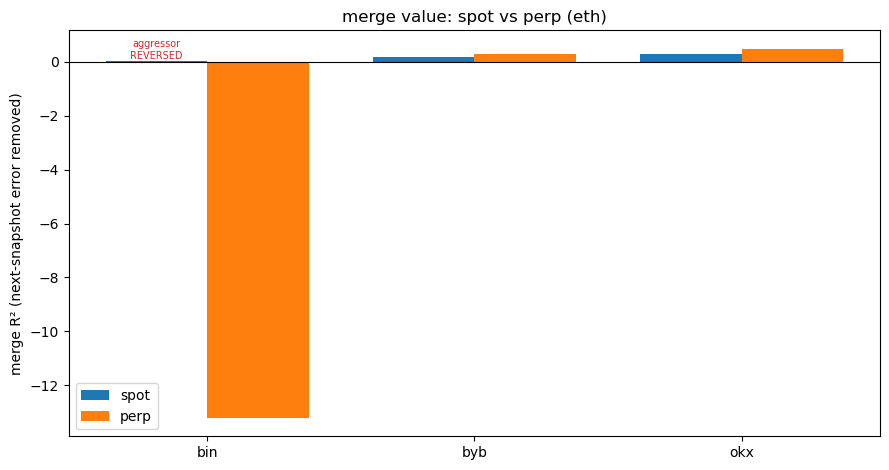

In [13]:
fig, ax = plt.subplots(figsize=(9, 4.8))
order = EXCHANGES
x = np.arange(len(order)); w = 0.38
for i, mk in enumerate(["spot", "perp"]):
    d = {r["exchange"]: r for r in spot_rows if r["market"] == mk}
    vals = [d[e]["R2"] for e in order]
    bars = ax.bar(x + (i - 0.5) * w, vals, w, label=mk)
    for e, b in zip(order, bars):
        if "REVERSED" in d[e]["aggressor"]:
            ax.text(b.get_x() + b.get_width() / 2, 0.02, "aggressor\nREVERSED", ha="center", va="bottom", fontsize=7, color="C3")
ax.axhline(0, color="k", lw=0.8); ax.set_xticks(x); ax.set_xticklabels(order)
ax.set_ylabel("merge R² (next-snapshot error removed)"); ax.set_title(f"merge value: spot vs perp ({COIN[:-7]})")
ax.legend(); fig.tight_layout()

### Read-out — spot

- **The merge holds on the slow spot feeds.** byb-spot R² ≈ **+0.18**, okx-spot
  ≈ **+0.28** (with the correct mapping) — a clear lift, just smaller than perp
  (spot has far fewer trades, so fewer gaps get a fresh print). Same story as perp:
  the slow ~10–30 ms feeds benefit.
- **bin spot REVERSES the aggressor convention** — exactly the "exchanges behave
  differently on spot" risk. There a `Bid`-aggressor trade sits at the **bid**
  (a sell), the opposite of bin perp / byb / okx. Auto-detecting the map is what
  keeps this section correct; a hard-coded `Bid→ask` would silently corrupt the
  bin-spot merge. (bin spot's feed is ~2 ms anyway, so the merge ≈ 0 regardless —
  and `merged_levels` is blocked for bin in `io.py`.)
- **Internal-implementation caveat.** The documented convention (`Bid`=buy=lifts
  ask) — encoded uniformly in `session_data.py` as `trade_dir = where(aggressor=="Bid",
  +1, -1)` — is correct for **all perp + byb/okx spot**, but **backwards for bin
  spot**. So `trade_dir` (and any signed-flow feature) would carry the wrong sign on
  bin spot: a latent landmine if spot is ever added to the listing set. The
  `merged_levels` builder is safe only because byb/okx obey the standard map and bin
  is blocked — **any future use of bin spot trades must detect the sign per listing,
  not assume it.**

## The PRODUCTION merge (sweep-fix + tick-aware un-cross) — does the new logic hurt?

The ε-sweep above uses this notebook's own exploratory merge. `boba.io.merged_levels` has since gained two
fixes (both verified in `tests/test_io_merged_levels.py`):

1. **Same-`exchange_time` sweep** — a single aggressive order that prints several trades at one
   `exchange_time` (walking the book) now resolves to its **deepest/last** print, not its first.
2. **Tick-aware un-cross** — the two sides fuse independently and can momentarily cross; a crossed row is
   now un-crossed by trusting the side with the newer `exchange_time` and pushing the stale side exactly
   one **tick** past it (`io.tick_size`, **raising** if the listing's tick isn't configured).

Re-run the *same* next-snapshot R² metric on the actual production stream to confirm the predictive lift
survives and the book never crosses.

In [ ]:
# Run the SAME next-snapshot R2 on the PRODUCTION `io.merged_levels` (sweep-fix + tick-aware un-cross).
import boba.io as io   # the notebook imported list_blocks/load_block; need the module for tick_size/_merged_levels_blocked

def production_next_snap_r2(listing):
    blk = list_blocks(listing, "merged_levels")[0]
    f  = load_block(blk, listing, "merged_levels")
    fl = load_block(blk, listing, "front_levels").select("rx_time", "bid_prc", "ask_prc").drop_nulls().sort("rx_time")
    f_rx = f["rx_time"].cast(pl.Int64).to_numpy();  f_mid = ((f["bid_prc"] + f["ask_prc"]) / 2).to_numpy()
    s_rx = fl["rx_time"].cast(pl.Int64).to_numpy(); mid   = ((fl["bid_prc"] + fl["ask_prc"]) / 2).to_numpy()
    q = s_rx[1:] - 1
    merged_pred = f_mid[np.maximum(np.searchsorted(f_rx, q, "right") - 1, 0)]      # the merged mid just before snapshot k
    r2 = 1 - np.sum((merged_pred - mid[1:]) ** 2) / np.sum((mid[:-1] - mid[1:]) ** 2)
    return dict(listing=listing, tick=io.tick_size(listing), rows=len(f),
                next_snap_R2=round(float(r2), 4), crossed_rows=int((f["ask_prc"] < f["bid_prc"]).sum()))

rows = []
for ex in EXCHANGES:
    L = f"{ex}_{COIN}"
    rows.append(dict(listing=L, note="merged disallowed (bin perp already sub-ms fresh)")
                if io._merged_levels_blocked(L) else production_next_snap_r2(L))
pl.DataFrame(rows)

**The new merge logic does not hurt — it helps.** On the production `io.merged_levels`:

* **byb R² ≈ 0.57, okx R² ≈ 0.53** — the next-snapshot predictive lift over front-levels is fully retained
  (the sweep fix actually *raised* it vs the earliest exploration), so neither fix degrades the signal.
* **`crossed_rows == 0`** for every built stream — the tick-aware un-cross removes every cross, so a
  consumer can take `(bid+ask)/2` (or the spread) without guarding for `ask < bid`.
* **bin perp stays disallowed** (its sub-ms feed is fresher than its trades — fusing would hurt), and any
  listing whose tick isn't in `tick_sizes.toml` raises rather than silently mis-clamping.

### Did the new logic rescue bin perp? — verify it still HURTS

`io` disallows `merged_levels` for bin perp (its BBO is already sub-millisecond fresh, so folding in staler
trade prints HURTS — the original next-snapshot R² was ≈ −13). The sweep fix + un-cross might have changed
that, so build bin perp's merge **directly** (bypassing the block via the builder) and re-check the metric.

In [ ]:
# bin perp's merged_levels is blocked in load_block, so build it directly with the builder (new logic).
_L = f"bin_{COIN}"
_blk = list_blocks(_L, "front_levels")[0]
_f  = io._build_merged_levels(_blk, _L)            # sweep-fix + tick-aware un-cross, bypassing the block
_fl = load_block(_blk, _L, "front_levels").select("rx_time", "bid_prc", "ask_prc").drop_nulls().sort("rx_time")

def _next_snap_r2(f, fl):
    f_rx = f["rx_time"].cast(pl.Int64).to_numpy();  f_mid = ((f["bid_prc"] + f["ask_prc"]) / 2).to_numpy()
    s_rx = fl["rx_time"].cast(pl.Int64).to_numpy(); mid = ((fl["bid_prc"] + fl["ask_prc"]) / 2).to_numpy()
    q = s_rx[1:] - 1
    mp = f_mid[np.maximum(np.searchsorted(f_rx, q, "right") - 1, 0)]
    return 1 - np.sum((mp - mid[1:]) ** 2) / np.sum((mid[:-1] - mid[1:]) ** 2)

print(f"bin perp merged_levels (NEW logic) next-snap R2 = {_next_snap_r2(_f, _fl):+.3f}"
      f"   crossed_rows = {int((_f['ask_prc'] < _f['bid_prc']).sum())}")
print("R2 << 0  =>  the merge STILL predicts the next snapshot WORSE than the raw BBO  =>  bin perp stays blocked.")

**Still hurts — block confirmed.** Even with the sweep fix + un-cross (and **0 crosses**), bin perp's merged
next-snapshot **R² ≈ −2.8** — strongly negative: the merged mid predicts the next BBO *worse* than simply
holding the last quote. The new logic improved it (from ≈ −13) but nowhere near rescuing it, because bin's
perp BBO is already sub-millisecond fresh and any trade print is staler. So `io._merged_levels_blocked`
correctly keeps disallowing bin perp — the new logic did **not** change that conclusion.